In [ ]:
import requests
from dotenv import load_dotenv
import os
import pandas as pd
import rasterio
import numpy as np
import glob
import geopandas as gpd
from rasterstats import zonal_stats

load_dotenv('../envs/dev.env')

token = os.getenv("HCDP_ADMIN_TOKEN")
local_dep_dir = os.environ.get('DEPENDENCY_DIR')

headers = {
    "Authorization": f"Bearer {token}"
}

In [16]:
url = "https://api.hcdp.ikewai.org/raster?date=2015-01&location=hawaii&datatype=spi&extent=statewide&production=new&timescale=timescale012&period=month"
response = requests.get(url, headers=headers)
response.json()

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [31]:
url = "https://api.hcdp.ikewai.org/mesonet/climate_report/drought_stats"
# rainfall_stats, temperature_stats, drought_stats, rainfall_historical, or temperature_historical
#islands: Moloka‘i, Lāna‘i
query_params = {
    "startDate"
  : 
  "2025-07",
  "endDate":
  "2026-06",
  "division_type"
  : 
  "Statewide",
  "island"
  : 
  "Statewide",
  "name"
  : 
  "Statewide"
}

response = requests.get(url, params=query_params, headers=headers)
response.json()

[{'island': 'Statewide',
  'division_type': 'Statewide',
  'name': 'Statewide',
  'date': '2025-07-01T00:00:00.000Z',
  'd4': '0.29',
  'd3': '2.62',
  'd2': '5.93',
  'd1': '19.77',
  'd0': '13.17',
  'near_normal': '52.22',
  'w0': '3.37',
  'w1': '1.74',
  'w2': '0.41',
  'w3': '0.46',
  'w4': '0.01'},
 {'island': 'Statewide',
  'division_type': 'Statewide',
  'name': 'Statewide',
  'date': '2025-08-01T00:00:00.000Z',
  'd4': '2.27',
  'd3': '7.68',
  'd2': '11.05',
  'd1': '28.67',
  'd0': '17.31',
  'near_normal': '29.7',
  'w0': '1.87',
  'w1': '0.82',
  'w2': '0.27',
  'w3': '0.16',
  'w4': '0.21'},
 {'island': 'Statewide',
  'division_type': 'Statewide',
  'name': 'Statewide',
  'date': '2025-09-01T00:00:00.000Z',
  'd4': '1.44',
  'd3': '6.27',
  'd2': '13.48',
  'd1': '29.18',
  'd0': '20.9',
  'near_normal': '27.06',
  'w0': '0.53',
  'w1': '0.63',
  'w2': '0.18',
  'w3': '0.1',
  'w4': '0.23'},
 {'island': 'Statewide',
  'division_type': 'Statewide',
  'name': 'Statewide',


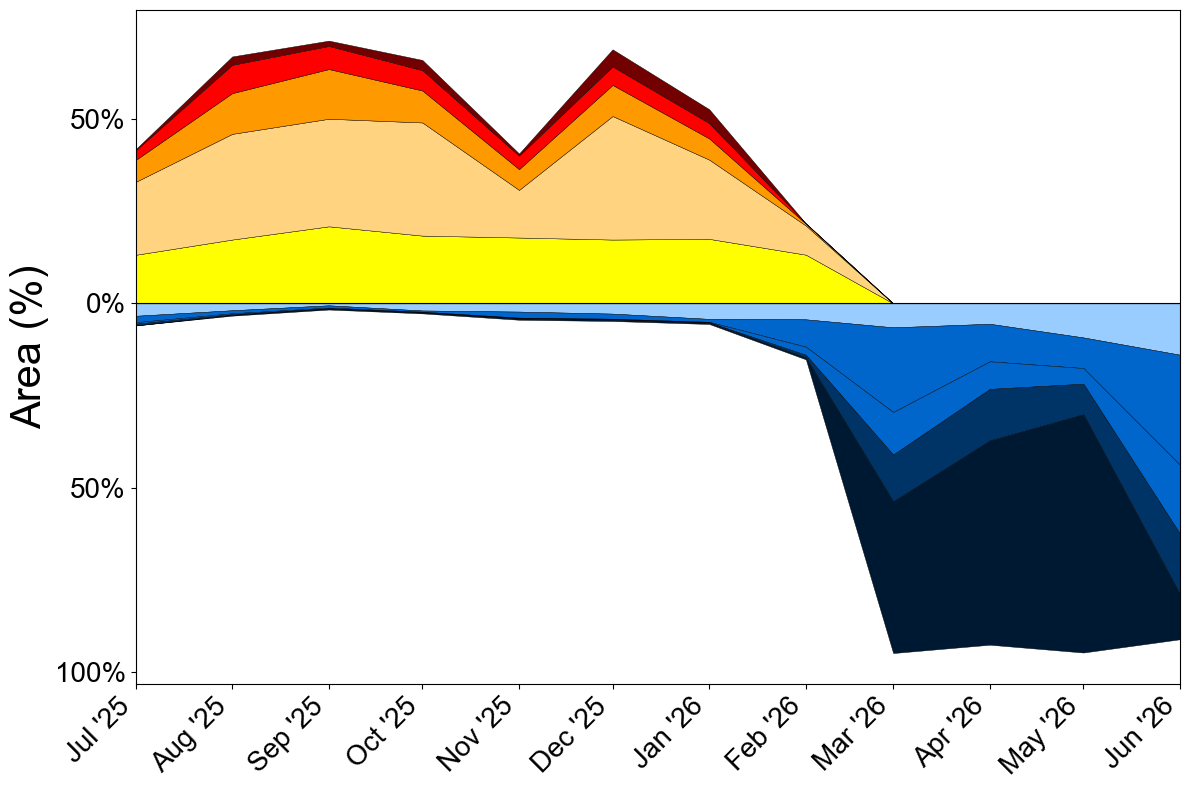

In [42]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

df = pd.DataFrame(response.json())
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Matches data-highchart.component.ts: drought stacked above 0 (D0 nearest the
# baseline out to D4), wet stacked below 0 (W0 nearest the baseline out to W4).
drought = [
    ('d0', 'D0 Abnormally Dry',      '#FFFF00'),
    ('d1', 'D1 Moderate Drought',    '#FFD37F'),
    ('d2', 'D2 Severe Drought',      '#FF9900'),
    ('d3', 'D3 Extreme Drought',     '#FF0000'),
    ('d4', 'D4 Exceptional Drought', '#730000'),
]
wet = [
    ('w0', 'W0 Abnormally Wet',      '#99CCFF'),
    ('w1', 'W1 Moderately Wet',      '#0066CC'),
    ('w2', 'W2 Severely Wet',        '#0066CC'),
    ('w3', 'W3 Extremely Wet',       '#003366'),
    ('w4', 'W4 Exceptionally Wet',   '#001933'),
]

for col, _, _ in drought + wet:
    df[col] = df[col].astype(float)

fig, ax = plt.subplots(figsize=(12, 8))

ax.stackplot(
    df['date'],
    [df[col] for col, _, _ in drought],
    labels=[label for _, label, _ in drought],
    colors=[color for _, _, color in drought],
    edgecolor='black',
    linewidth=0.3,
)
ax.stackplot(
    df['date'],
    [-df[col] for col, _, _ in wet],
    labels=[label for _, label, _ in wet],
    colors=[color for _, _, color in wet],
    edgecolor='black',
    linewidth=0.3,
)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlim(df['date'].min(), df['date'].max())
ax.set_ylabel('Area (%)', fontsize=30)
# ax.set_title('Hawaiʻi Statewide Drought/Wetness Distribution, July 2025–June 2026')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=20)
plt.setp(ax.get_yticklabels(), fontsize=20)
# y-axis shows the same absolute percentage above and below the zero line
ax.yaxis.set_major_locator(mticker.MultipleLocator(50))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{abs(v):.0f}%'))

# # legend ordered D4->D0, W0->W4 (matches the tooltip order in data-highchart.component.ts)
# handles, labels_ = ax.get_legend_handles_labels()
# by_label = dict(zip(labels_, handles))
# legend_order = [
#     'D4 Exceptional Drought', 'D3 Extreme Drought', 'D2 Severe Drought',
#     'D1 Moderate Drought', 'D0 Abnormally Dry',
#     'W0 Abnormally Wet', 'W1 Moderately Wet', 'W2 Severely Wet',
#     'W3 Extremely Wet', 'W4 Exceptionally Wet',
# ]
# ax.legend(
#     [by_label[l] for l in legend_order],
#     legend_order,
#     loc='upper left',
#     bbox_to_anchor=(1.02, 1),
#     frameon=False,
#     fontsize=9,
# )

plt.tight_layout()
plt.show()

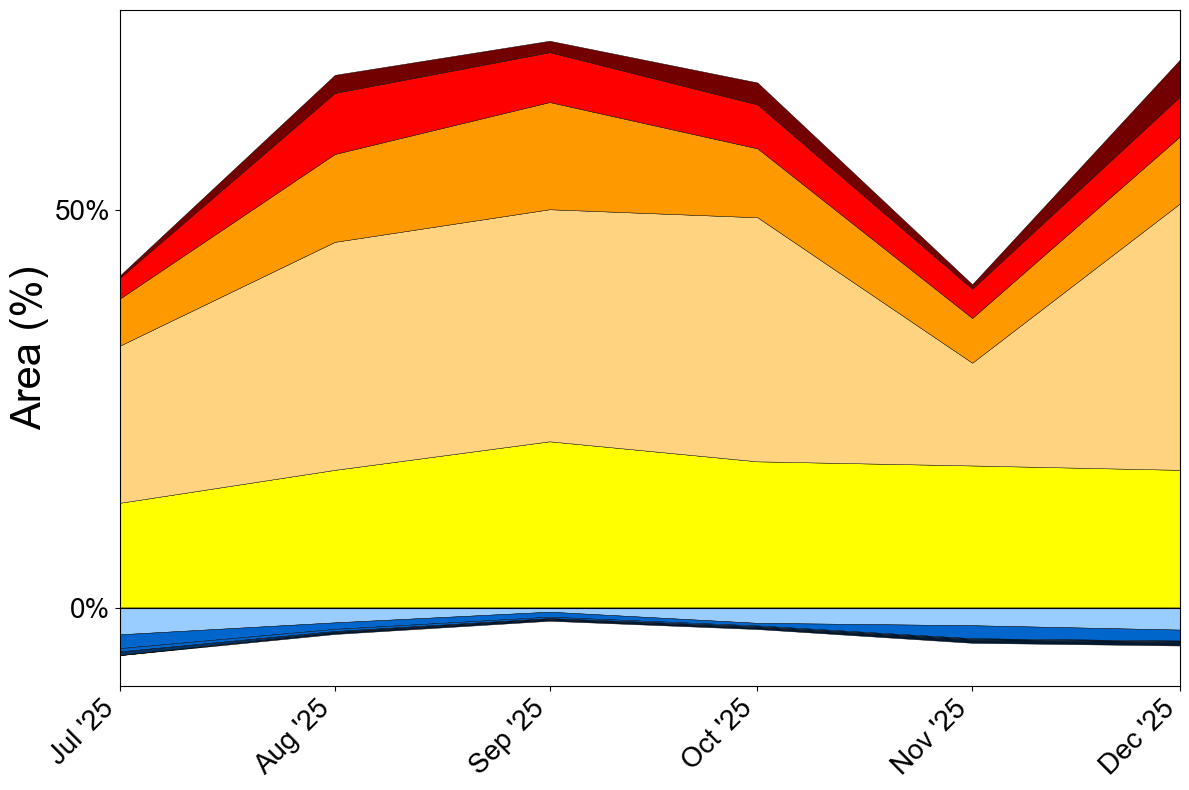

In [43]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

df = pd.DataFrame(response.json())
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df = df.iloc[:6]

drought = [
    ('d0', 'D0 Abnormally Dry',      '#FFFF00'),
    ('d1', 'D1 Moderate Drought',    '#FFD37F'),
    ('d2', 'D2 Severe Drought',      '#FF9900'),
    ('d3', 'D3 Extreme Drought',     '#FF0000'),
    ('d4', 'D4 Exceptional Drought', '#730000'),
]
wet = [
    ('w0', 'W0 Abnormally Wet',      '#99CCFF'),
    ('w1', 'W1 Moderately Wet',      '#0066CC'),
    ('w2', 'W2 Severely Wet',        '#0066CC'),
    ('w3', 'W3 Extremely Wet',       '#003366'),
    ('w4', 'W4 Exceptionally Wet',   '#001933'),
]

for col, _, _ in drought + wet:
    df[col] = df[col].astype(float)

fig, ax = plt.subplots(figsize=(12, 8))

ax.stackplot(
    df['date'],
    [df[col] for col, _, _ in drought],
    labels=[label for _, label, _ in drought],
    colors=[color for _, _, color in drought],
    edgecolor='black',
    linewidth=0.3,
)
ax.stackplot(
    df['date'],
    [-df[col] for col, _, _ in wet],
    labels=[label for _, label, _ in wet],
    colors=[color for _, _, color in wet],
    edgecolor='black',
    linewidth=0.3,
)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlim(df['date'].min(), df['date'].max())
ax.set_ylabel('Area (%)', fontsize=30)

# ax.set_title('Hawaiʻi Statewide Drought/Wetness Distribution, July 2025–June 2026')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=20)
plt.setp(ax.get_yticklabels(), fontsize=20)

# y-axis shows the same absolute percentage above and below the zero line
ax.yaxis.set_major_locator(mticker.MultipleLocator(50))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{abs(v):.0f}%'))

handles, labels_ = ax.get_legend_handles_labels()
by_label = dict(zip(labels_, handles))
legend_order = [
    'D4 Exceptional Drought', 'D3 Extreme Drought', 'D2 Severe Drought',
    'D1 Moderate Drought', 'D0 Abnormally Dry',
    'W0 Abnormally Wet', 'W1 Moderately Wet', 'W2 Severely Wet',
    'W3 Extremely Wet', 'W4 Exceptionally Wet',
]
# ax.legend(
#     [by_label[l] for l in legend_order],
#     legend_order,
#     loc='upper left',
#     bbox_to_anchor=(1.02, 1),
#     frameon=False,
#     fontsize=9,
# )

plt.tight_layout()
plt.show()

In [15]:
df

,island,division_type,name,date,d4,d3,d2,d1,d0,near_normal,w0,w1,w2,w3,w4
0,Statewide,Statewide,Statewide,2025-07-01 00:00:00+00:00,0.29,2.62,5.93,19.77,13.17,52.22,3.37,1.74,0.41,0.46,0.01
1,Statewide,Statewide,Statewide,2025-08-01 00:00:00+00:00,2.27,7.68,11.05,28.67,17.31,29.7,1.87,0.82,0.27,0.16,0.21
2,Statewide,Statewide,Statewide,2025-09-01 00:00:00+00:00,1.44,6.27,13.48,29.18,20.90,27.06,0.53,0.63,0.18,0.10,0.23
3,Statewide,Statewide,Statewide,2025-10-01 00:00:00+00:00,2.76,5.52,8.67,30.69,18.38,31.26,1.93,0.33,0.11,0.13,0.21
4,Statewide,Statewide,Statewide,2025-11-01 00:00:00+00:00,0.57,3.67,5.63,12.92,17.86,54.9,2.23,1.64,0.09,0.11,0.37
5,Statewide,Statewide,Statewide,2025-12-01 00:00:00+00:00,4.65,5.01,8.43,33.51,17.31,26.3,2.78,1.38,0.10,0.11,0.41
6,Statewide,Statewide,Statewide,2026-01-01 00:00:00+00:00,3.76,4.16,5.75,21.49,17.50,41.74,4.21,0.80,0.12,0.10,0.36
7,Statewide,Statewide,Statewide,2026-02-01 00:00:00+00:00,0.00,0.08,0.50,7.90,13.21,63.12,4.33,7.42,2.22,0.71,0.50
8,Statewide,Statewide,Statewide,2026-03-01 00:00:00+00:00,0.00,0.00,0.00,0.00,0.00,5.16,6.50,22.97,11.55,12.71,41.11
9,Statewide,Statewide,Statewide,2026-04-01 00:00:00+00:00,0.00,0.00,0.00,0.00,0.00,7.43,5.54,10.18,7.48,14.00,55.38


In [ ]:
import matplotlib.pyplot as plt

# Bin colors match climate-summary-2025.component.ts legends exactly
# (rainfallLegendItems.pdiff and temperatureLegendItems.anom)
def rainfall_pct_color(v):
    if v > 70: return '#001a4d'
    elif v > 50: return '#2f7dff'
    elif v > 30: return '#7fc3ff'
    elif v > 10: return '#cfefff'
    elif v >= -10: return '#ffffff'
    elif v >= -30: return '#ff5a1f'
    elif v >= -50: return '#c00000'
    elif v >= -70: return '#7f0000'
    else: return '#4b0000'

def temp_color(v):
    if v > 1.75: return '#730000'
    elif v > 1.25: return '#FF0000'
    elif v > 0.75: return '#FF9900'
    elif v > 0.25: return '#ffe1c2'
    elif v >= -0.25: return '#FFFFFF'
    elif v >= -0.75: return '#cfe8ff'
    elif v >= -1.25: return '#66a3ff'
    elif v >= -1.75: return '#0066CC'
    else: return '#003d80'

def text_color(hexcolor):
    r, g, b = (int(hexcolor[i:i+2], 16) for i in (1, 3, 5))
    lum = 0.2126 * r + 0.7152 * g + 0.0722 * b
    return 'white' if lum < 140 else 'black'

rainfall = [
    ('Jan', 3.9, 42, None),
    ('Feb', 0.8, 8, None),
    ('Mar', 5.0, 40, '2nd wettest'),
    ('Apr', -0.2, -2, None),
    ('May', 5.2, 66, None),
    ('Jun', 2.4, 32, '3rd wettest'),
]

temperature = [
    ('Jan', 0.9, None),
    ('Feb', 0.1, None),
    ('Mar', 1.5, '#5 warmest'),
    ('Apr', 1.4, '#2 warmest'),
    ('May', 0.4, None),
    ('Jun', 0.4, None),
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.2))

for ax, title in ((ax1, 'Rainfall'), (ax2, 'Temperature')):
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold', loc='left')

rows = len(rainfall)
row_h = 1 / rows
for i, (month, inches, pct, rank) in enumerate(rainfall):
    y = 1 - (i + 1) * row_h
    color = rainfall_pct_color(pct)
    fg = text_color(color)
    ax1.add_patch(plt.Rectangle((0.28, y), 0.72, row_h, facecolor=color, edgecolor='#cccccc', linewidth=0.6, transform=ax1.transAxes, clip_on=False))
    ax1.text(0.02, y + row_h / 2, month, ha='left', va='center', fontsize=11, transform=ax1.transAxes)
    label = f"{inches:+.1f}in  {pct:+d}%"
    ax1.text(0.30, y + row_h / 2, label, ha='left', va='center', fontsize=11, color=fg, transform=ax1.transAxes)
    if rank:
        ax1.text(0.98, y + row_h / 2, rank, ha='right', va='center', fontsize=9.5, color=fg, style='italic', transform=ax1.transAxes)

rows = len(temperature)
row_h = 1 / rows
for i, (month, deg, rank) in enumerate(temperature):
    y = 1 - (i + 1) * row_h
    color = temp_color(deg)
    fg = text_color(color)
    ax2.add_patch(plt.Rectangle((0.28, y), 0.72, row_h, facecolor=color, edgecolor='#cccccc', linewidth=0.6, transform=ax2.transAxes, clip_on=False))
    ax2.text(0.02, y + row_h / 2, month, ha='left', va='center', fontsize=11, transform=ax2.transAxes)
    label = f"{deg:+.1f}°F"
    ax2.text(0.30, y + row_h / 2, label, ha='left', va='center', fontsize=11, color=fg, transform=ax2.transAxes)
    if rank:
        ax2.text(0.98, y + row_h / 2, rank, ha='right', va='center', fontsize=9.5, color=fg, style='italic', transform=ax2.transAxes)

fig.suptitle('2026 Monthly Departure from Normal — Statewide', fontsize=12, y=1.04)
plt.tight_layout()
plt.show()

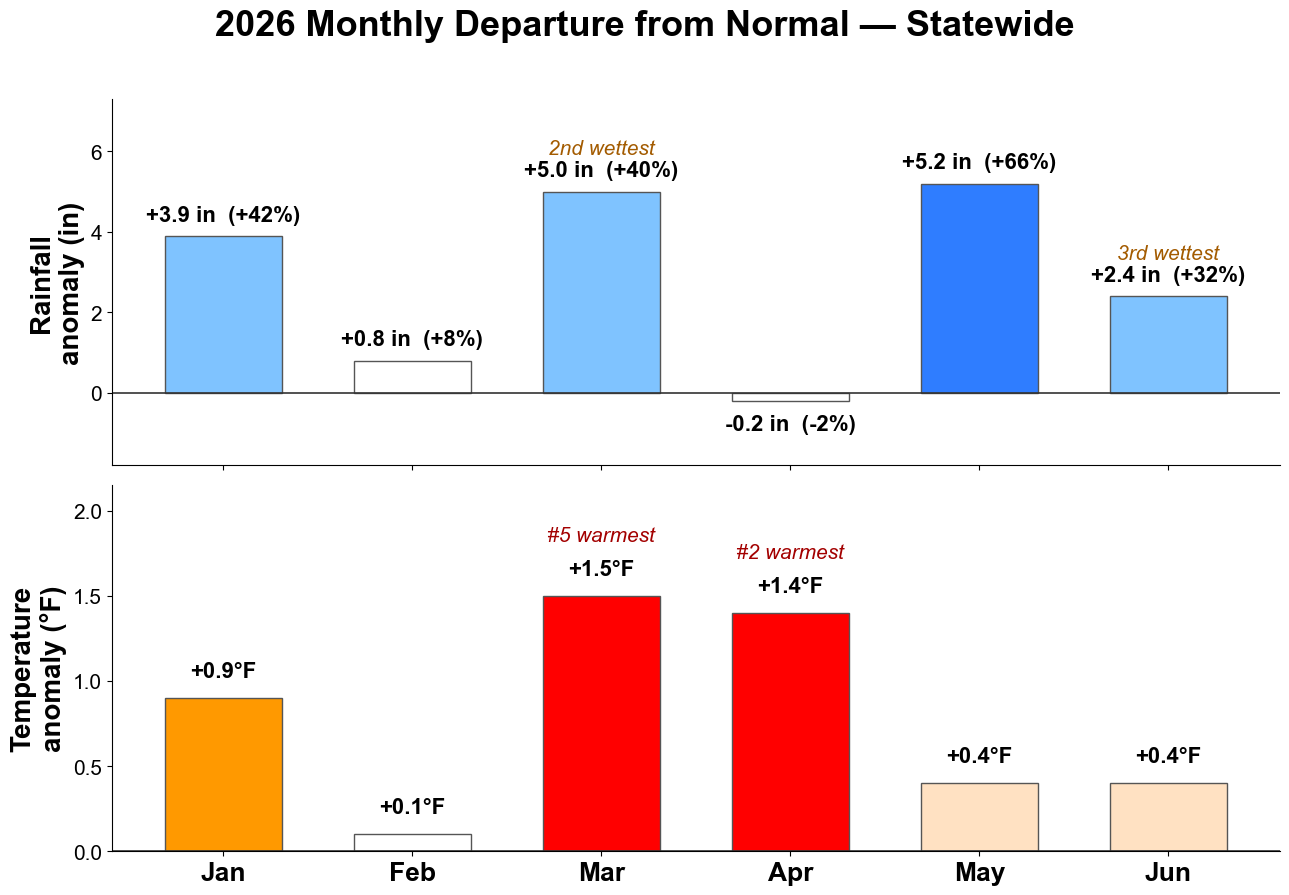

In [29]:
# Rainfall/temperature anomaly bar chart — sized and styled for a PowerPoint slide
import numpy as np

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
rf_in = [3.9, 0.8, 5.0, -0.2, 5.2, 2.4]
rf_pct = [42, 8, 40, -2, 66, 32]
rf_rank = {2: '2nd wettest', 5: '3rd wettest'}  # index -> label

t_deg = [0.9, 0.1, 1.5, 1.4, 0.4, 0.4]
t_rank = {2: '#5 warmest', 3: '#2 warmest'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
x = np.arange(len(months))

# --- Rainfall panel ---
ax1.bar(x, rf_in, color=[rainfall_pct_color(p) for p in rf_pct],
        edgecolor='#555', linewidth=1, width=0.62)
ax1.axhline(0, color='#333', linewidth=1.2)
ax1.set_ylabel('Rainfall\nanomaly (in)', fontsize=20, fontweight='bold')
for i, (v, pct) in enumerate(zip(rf_in, rf_pct)):
    va = 'bottom' if v >= 0 else 'top'
    off = 0.28 if v >= 0 else -0.32
    label = f"{v:+.1f} in  ({pct:+d}%)"
    ax1.text(i, v + off, label, ha='center', va=va, fontsize=16, fontweight='bold')
    if i in rf_rank:
        rank_off = off + (0.55 if v >= 0 else -0.55)
        ax1.text(i, v + rank_off, rf_rank[i], ha='center', va=va,
                  fontsize=15, style='italic', color='#a35b00')
ax1.set_ylim(-1.8, 7.3)
ax1.tick_params(axis='y', labelsize=15)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- Temperature panel ---
ax2.bar(x, t_deg, color=[temp_color(d) for d in t_deg],
        edgecolor='#555', linewidth=1, width=0.62)
ax2.axhline(0, color='#333', linewidth=1.2)
ax2.set_ylabel('Temperature\nanomaly (°F)', fontsize=20, fontweight='bold')
for i, v in enumerate(t_deg):
    label = f"{v:+.1f}°F"
    ax2.text(i, v + 0.10, label, ha='center', va='bottom', fontsize=16, fontweight='bold')
    if i in t_rank:
        ax2.text(i, v + 0.30, t_rank[i], ha='center', va='bottom',
                  fontsize=15, style='italic', color='#a30000')
ax2.set_ylim(0, 2.15)
ax2.set_xticks(x)
ax2.set_xticklabels(months, fontsize=19, fontweight='bold')
ax2.tick_params(axis='y', labelsize=15)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

fig.suptitle('2026 Monthly Departure from Normal — Statewide', fontsize=26, fontweight='bold', y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('climate_summary_2026.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()